In [1]:
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

from lime.lime_tabular import LimeTabularExplainer
import shap
from collections import defaultdict
import re
import sys
from io import StringIO

In [2]:
cali_housing_path = '../data/California_Houses.csv'
RANDOM_SEED = 492
cali_df = pd.read_csv(cali_housing_path)
y_series = cali_df['Median_House_Value']
y = pd.DataFrame(y_series, columns=['Median_House_Value'])
features = [col for col in cali_df.columns if col != 'Median_House_Value']
X = cali_df[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

np.random.seed(RANDOM_SEED)
y_train_shuffled = y_train.copy()
y_train_shuffled['Median_House_Value'] = np.random.permutation(y_train_shuffled['Median_House_Value'].values)

In [3]:
print(X_train.shape)

(16512, 13)


In [70]:
import tensorflow as tf
from tensorflow.keras.layers import LayerNormalization, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MultiHeadAttention
from lime.lime_tabular import LimeTabularExplainer
import shap
import numpy as np
import pandas as pd


class FeatureTokenizer(tf.keras.layers.Layer):
    def __init__(self, num_features, embed_dim):
        super(FeatureTokenizer, self).__init__()
        self.num_features = num_features
        self.embed_dim = embed_dim
        
        self.feature_weights = self.add_weight(shape=(num_features, embed_dim),
                                               initializer='random_normal',
                                               trainable=True)
        self.feature_bias = self.add_weight(shape=(num_features, embed_dim),
                                            initializer='random_normal',
                                            trainable=True)
        self.layer_norm = LayerNormalization()
    
    def call(self, inputs):
        # Remove unnecessary extra dimension
        print("Inputs shape before expansion in tokenizer call:", inputs.shape)
        
        embeddings = inputs[:, :, tf.newaxis] * self.feature_weights + self.feature_bias
        print("Embeddings shape after expansion and weight application in tokenizer call:", embeddings.shape)
        embeddings = self.layer_norm(embeddings)
        print("Embeddings shape after layer normalization in tokenizer call:", embeddings.shape)
        return embeddings


class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, attention_mask=None, training=False):
        attn_output = self.att(inputs, inputs) #, inputs, attention_mask=attention_mask
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class FTTransformer(tf.keras.Model):
    def __init__(self, embed_dim, dim_out, depth, heads, ff_dim, mlp_hidden, attn_dropout=0.1, ff_dropout=0.1):
        super(FTTransformer, self).__init__()
        self.transformers = [TransformerBlock(embed_dim, heads, ff_dim, rate=attn_dropout) for _ in range(depth)]
        # self.flatten_transformer_output = Flatten()
        self.global_pooling = tf.keras.layers.GlobalAveragePooling1D()
        self.mlp_layers = [Dense(size, activation=activation) for size, activation in mlp_hidden]
        self.output_layer = Dense(dim_out)
    
    def call(self, inputs, attention_mask=None, training=False):
        print("Input shape to Transformer:", inputs.shape)
        x = inputs
        for transformer in self.transformers:
            x = transformer(x, attention_mask=attention_mask, training=training)
            print("Shape after Transformer block:", x.shape)
        x = self.global_pooling(x)
        print("Shape after Global pooling:", x.shape)
        for mlp_layer in self.mlp_layers:
            x = mlp_layer(x)
            print("Shape after MLP layer:", x.shape)
        return self.output_layer(x)


class SimpleMLPModel(tf.keras.Model):
    def __init__(self, num_features, embed_dim, dim_out=1, depth=2, heads=4, ff_dim=128, mlp_hidden=[(128, 'relu'), (64, 'relu')], hidden_dim=64, dropout_rate=0.1):
        super(SimpleMLPModel, self).__init__()
        self.feature_tokenizer = FeatureTokenizer(num_features, embed_dim)
        self.transformer = FTTransformer(embed_dim, dim_out, depth, heads, ff_dim, mlp_hidden)
        self.dense1 = Dense(hidden_dim, activation='relu')
        self.dropout1 = Dropout(dropout_rate)
        self.dense2 = Dense(hidden_dim, activation='relu')
        self.dropout2 = Dropout(dropout_rate)
        self.dense3 = Dense(1, activation='linear')
        self.heads = heads
        
    def call(self, inputs, attention_mask=None, training=False):
        
        inputs = self.feature_tokenizer(inputs, training=training)
        print(f"Shape after feature_tokenizer in model call: {inputs.shape}")
        assert len(inputs.shape) == 3, f"Expected 3D inputs, got {inputs.shape}"
        batch_size = tf.shape(inputs)[0]
        seq_length = tf.shape(inputs)[1]
        
        if attention_mask is None:
            attention_mask = tf.ones((batch_size, seq_length, seq_length), dtype=tf.float32)
        print(f"Attention mask shape: {attention_mask.shape}")
        
        bert_output = self.transformer(inputs, attention_mask=attention_mask, training=training)
        print(f"Shape after transformer: {bert_output.shape}")
        x = self.dense1(bert_output)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.dropout2(x, training=training)
        x = self.dense3(x)
        return x
    
    def predict_with_uncertainty(self, inputs, num_samples=10):
        predictions = []
        print("Shape of input in predict_with_uncertainty:", inputs.shape)
        for i in range(num_samples):
            prediction = self(inputs, training=True)
            predictions.append(prediction)
            print(f"{i} out of {num_samples} inference done.")
        predictions = tf.stack(predictions, axis=0)
        pred_mean = tf.reduce_mean(predictions, axis=0)
        pred_std = tf.math.reduce_std(predictions, axis=0)
        return pred_mean.numpy(), pred_std.numpy()  # Convert to numpy for LIME and SHAP
    
    def predict_mean(self, inputs):
        pred_mean, _ = self.predict_with_uncertainty(inputs)
        return pred_mean
    
    def lime_predict_fn(self, data):
        data_tensor = tf.convert_to_tensor(data, dtype=tf.float32)
        predictions = self(data_tensor, training=False)
        return predictions.numpy().flatten()
    
    def predict_and_explain(self, inputs, X_train, num_samples=10):
        try:
            predictions = []
            lime_explanations = []
            shap_explanations = []
    
            # Convert inputs to numpy if it's a tensor
            if isinstance(inputs, tf.Tensor):
                inputs = inputs.numpy()
            
            # Ensure inputs is 2D
            if len(inputs.shape) == 1:
                inputs = inputs.reshape(1, -1)
    
            # LIME setup
            feature_names=X_train.columns.tolist()
            lime_explainer = LimeTabularExplainer(
                training_data=X_train.values if isinstance(X_train, pd.DataFrame) else X_train,
                mode='regression',
                feature_names=feature_names
            )
    
            # Summarize background data with k-means
            num_clusters = min(100, X_train.shape[0])
            X_train_values = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
            X_train_clustered = shap.kmeans(X_train_values, num_clusters)
            shap_explainer = shap.KernelExplainer(self.predict_mean, X_train_clustered)
    
            # Iterate over each instance
            for i in range(inputs.shape[0]):
                instance_predictions = []
                instance_lime_explanations = []
                instance_shap_explanations = []
                
                # Get the single instance using .iloc for integer-based indexing
                single_instance = inputs.iloc[i] if isinstance(inputs, pd.DataFrame) else inputs[i]
                single_instance = single_instance.values.reshape(1, -1) if isinstance(single_instance, pd.Series) else single_instance.reshape(1, -1)
                
                
                for _ in range(num_samples):
                    # Forward pass for single instance
                    pred = self(tf.convert_to_tensor(single_instance.reshape(1, -1)), training=True)
                    instance_predictions.append(pred)
    
                    # LIME explanation
                    try:
                        print(f"single_instance shape for LIME: {single_instance.shape}")
                        single_instance_flattened = single_instance.flatten()
                        print(f"single_instance_flattened shape for LIME: {single_instance_flattened.shape}")
                        lime_exp = lime_explainer.explain_instance(
                            single_instance_flattened, 
                            self.lime_predict_fn, 
                            num_features=inputs.shape[1]
                        )
                        instance_lime_explanations.append(lime_exp)
                    except Exception as lime_error:
                        print(f"LIME error: {str(lime_error)}")
                        instance_lime_explanations.append(None)
                    
                    # SHAP explanation
                    try:
                        shap_exp = shap_explainer.shap_values(single_instance.reshape(1, -1))
                        instance_shap_explanations.append(shap_exp)
                    except Exception as shap_error:
                        print(f"SHAP error: {str(shap_error)}")
                        instance_shap_explanations.append(None)
    
                predictions.append(instance_predictions)
                lime_explanations.append(instance_lime_explanations)
                shap_explanations.append(instance_shap_explanations)
    
            # Calculate mean and std for predictions
            predictions = tf.stack([tf.stack(instance_preds, axis=0) for instance_preds in predictions], axis=0)
            pred_mean = tf.reduce_mean(predictions, axis=1)
            pred_std = tf.math.reduce_std(predictions, axis=1)
    
            return pred_mean.numpy(), pred_std.numpy(), lime_explanations, shap_explanations
    
        except Exception as e:
            print(f"Error in predict_and_explain: {str(e)}")
            print(f"Inputs shape: {inputs.shape}")
            print(f"X_train shape: {X_train.shape}")
            raise ValueError(f"Error in predict_and_explain: {str(e)}")
    
    
    def predict_with_exp(self, inputs, X_train, num_samples=10):
        try:
            predictions = []
            lime_explanations = []
            shap_explanations = []
    
            # Convert inputs to numpy if it's a TensorFlow tensor
            if isinstance(inputs, tf.Tensor):
                inputs = inputs.numpy()
            
            # Ensure inputs is 2D
            if len(inputs.shape) == 1:
                inputs = inputs.reshape(1, -1)
    
            # LIME setup
            feature_names = [f'feature_{i}' for i in range(inputs.shape[1])]
            lime_explainer = LimeTabularExplainer(
                training_data=X_train.values if isinstance(X_train, pd.DataFrame) else X_train,
                mode='regression',
                feature_names=feature_names
            )
    
            # Summarize background data with k-means
            num_clusters = min(100, X_train.shape[0])
            X_train_values = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
            X_train_clustered = shap.kmeans(X_train_values, num_clusters)
            shap_explainer = shap.KernelExplainer(self.predict_mean, X_train_clustered)
    
            # Iterate over each instance
            for i in range(inputs.shape[0]):
                instance_predictions = []
                instance_lime_explanations = []
                instance_shap_explanations = []
                
                # Get the single instance
                single_instance = inputs[i]
                
                for _ in range(num_samples):
                    # Forward pass for single instance
                    pred = self(tf.convert_to_tensor(single_instance.reshape(1, -1)), training=True)
                    instance_predictions.append(pred)
    
                    # LIME explanation
                    try:
                        lime_exp = lime_explainer.explain_instance(
                            single_instance, 
                            lambda x: self(tf.convert_to_tensor(x.reshape(1, -1)), training=True).numpy().flatten(), 
                            num_features=inputs.shape[1]
                        )
                        instance_lime_explanations.append(lime_exp)
                    except Exception as lime_error:
                        print(f"LIME error: {str(lime_error)}")
                        instance_lime_explanations.append(None)
                    
                    # SHAP explanation
                    try:
                        shap_exp = shap_explainer.shap_values(single_instance.reshape(1, -1))
                        instance_shap_explanations.append(shap_exp)
                    except Exception as shap_error:
                        print(f"SHAP error: {str(shap_error)}")
                        instance_shap_explanations.append(None)
    
                predictions.append(instance_predictions)
                lime_explanations.append(instance_lime_explanations)
                shap_explanations.append(instance_shap_explanations)
    
            # Calculate mean and std for predictions
            predictions = tf.stack([tf.stack(instance_preds, axis=0) for instance_preds in predictions], axis=0)
            pred_mean = tf.reduce_mean(predictions, axis=1)
            pred_std = tf.math.reduce_std(predictions, axis=1)
    
            return pred_mean.numpy(), pred_std.numpy(), lime_explanations, shap_explanations
    
        except Exception as e:
            print(f"Error in predict_with_exp: {str(e)}")
            print(f"Inputs shape: {inputs.shape}")
            print(f"X_train shape: {X_train.shape}")
            raise ValueError(f"Error in predict_with_exp: {str(e)}")


# Initialize the model
input_dim = X_train_scaled.shape[1]  # Number of features
hidden_dim = 82
dropout_rate = 0.2
embed_dim = 20

model = SimpleMLPModel(num_features=input_dim, embed_dim=embed_dim, hidden_dim=hidden_dim, dropout_rate=dropout_rate)

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.1)

Epoch 1/50
Inputs shape before expansion in tokenizer call: (None, 13)
Embeddings shape after expansion and weight application in tokenizer call: (None, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (None, 13, 20)
Inputs shape before expansion in tokenizer call: (None, 13)
Embeddings shape after expansion and weight application in tokenizer call: (None, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (None, 13, 20)
Shape after feature_tokenizer in model call: (None, 13, 20)
Attention mask shape: (None, 13, 13)
Input shape to Transformer: (None, 13, 20)
Shape after Transformer block: (None, 13, 20)
Shape after Transformer block: (None, 13, 20)
Shape after Global pooling: (None, 20)
Shape after MLP layer: (None, 128)
Shape after MLP layer: (None, 64)
Input shape to Transformer: (None, 13, 20)
Shape after Transformer block: (None, 13, 20)
Shape after Transformer block: (None, 13, 20)
Shape after Global pooling: (None, 20)
Shape after MLP layer

In [180]:
# Test LIME with a simple function first to ensure it works independently
def test_lime_with_simple_function():
    import numpy as np

    # Simple function for testing
    def simple_predict_fn(data):
        return np.sum(data, axis=1)
    
    # Create some sample data
    np.random.seed(0)
    X_train_sample = np.random.rand(100, 5)
    X_test_sample = np.random.rand(1, 5)

    # Create the LIME explainer
    feature_names = [f'feature_{i}' for i in range(X_train_sample.shape[1])]
    lime_explainer = LimeTabularExplainer(X_train_sample, feature_names=feature_names, mode='regression')

    # Explain a single instance
    lime_exp = lime_explainer.explain_instance(X_test_sample[0], simple_predict_fn, num_features=5)
    lime_exp.show_in_notebook()
    
# Test LIME with a simple function first to ensure it works independently
test_lime_with_simple_function()

In [11]:
pred_mean, pred_uncertain = model.predict_with_uncertainty(X_test_scaled, num_samples=100)

Shape of input in predict_with_uncertainty: (4128, 13)
Inputs shape before expansion in tokenizer call: (4128, 13)
Embeddings shape after expansion and weight application in tokenizer call: (4128, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (4128, 13, 20)
Shape after feature_tokenizer in model call: (4128, 13, 20)
Attention mask shape: (4128, 13, 13)
Input shape to Transformer: (4128, 13, 20)
Shape after Transformer block: (4128, 13, 20)
Shape after Transformer block: (4128, 13, 20)
Shape after Global pooling: (4128, 20)
Shape after MLP layer: (4128, 128)
Shape after MLP layer: (4128, 64)
Shape after transformer: (4128, 1)
0 out of 100 inference done.
Inputs shape before expansion in tokenizer call: (4128, 13)
Embeddings shape after expansion and weight application in tokenizer call: (4128, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (4128, 13, 20)
Shape after feature_tokenizer in model call: (4128, 13, 20)
Attention mask shape: (4128

In [6]:
# evaluation with mse
y_test_eval = np.array(y_test).flatten()
y_pred_eval = pred_mean.flatten()
root_mse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
print(root_mse)

51884.72531036978


In [7]:
y_uncertainty = np.mean(pred_uncertain.flatten())
print(y_uncertainty)

23908.607


In [95]:
def randomize_weights(model):
    weights = model.get_weights()
    new_weights = []
    for w in weights:
        new_w = np.random.normal(size=w.shape)
        new_weights.append(new_w)
    model.set_weights(new_weights)
    
# Randomize weights
randomize_weights(model)
pred_mean, pred_uncertain = model.predict_with_uncertainty(X_test_scaled, num_samples=100)


Shape of input in predict_with_uncertainty: (4128, 13)
Inputs shape before expansion in tokenizer call: (4128, 13)
Embeddings shape after expansion and weight application in tokenizer call: (4128, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (4128, 13, 20)
Shape after feature_tokenizer in model call: (4128, 13, 20)
Attention mask shape: (4128, 13, 13)
Input shape to Transformer: (4128, 13, 20)
Shape after Transformer block: (4128, 13, 20)
Shape after Transformer block: (4128, 13, 20)
Shape after Global pooling: (4128, 20)
Shape after MLP layer: (4128, 128)
Shape after MLP layer: (4128, 64)
Shape after transformer: (4128, 1)
0 out of 100 inference done.
Inputs shape before expansion in tokenizer call: (4128, 13)
Embeddings shape after expansion and weight application in tokenizer call: (4128, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (4128, 13, 20)
Shape after feature_tokenizer in model call: (4128, 13, 20)
Attention mask shape: (4128

In [9]:
# evaluation with mse
y_test_eval = np.array(y_test).flatten()
y_pred_eval = pred_mean.flatten()
root_mse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
print(root_mse)
y_uncertainty = np.mean(pred_uncertain.flatten())
print(y_uncertainty)

235767.83529342318
7377.4277


In [196]:
# make a dataframe to save somethings
# y-test
gbt_cali_data = pd.DataFrame({'y_test':y_test_eval})
# predicted mean
gbt_cali_data['mean_predict'] = pred_mean
# predicted std
gbt_cali_data['predicted_uncertainty'] = pred_uncertain

In [197]:
print(gbt_cali_data.head())

     y_test  mean_predict  predicted_uncertainty
0  273700.0  300327.09375           34035.675781
1   66900.0   58748.03125            7042.915039
2  258700.0  162880.06250           18397.826172
3  183400.0  174603.59375           21420.402344
4  265600.0  290291.87500           32990.394531


In [71]:
combined_indices = [1112, 128]

In [72]:
X_test_scaled_selected = X_test_scaled.iloc[combined_indices]

In [73]:
y_tested = y_test.iloc[combined_indices]
y_tested_drop = y_tested.reset_index(drop=True)
print(y_tested)

      Median_House_Value
1112            204600.0
128             500001.0


In [74]:
print(X_test_scaled_selected)

      Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  Population  \
1112       0.204393   -0.294257   1.532613      1.470086    2.737771   
128        0.177005    1.853528   0.272282      1.027531   -0.240676   

      Households  Latitude  Longitude  Distance_to_coast  Distance_to_LA  \
1112    1.485636 -0.863799   0.881501          -0.353718       -0.887962   
128     0.870385  1.007441  -1.425102          -0.791652        1.173775   

      Distance_to_SanDiego  Distance_to_SanJose  Distance_to_SanFrancisco  
1112             -0.914228             0.881519                  0.887497  
128               1.176143            -1.287536                 -1.535265  


In [75]:
X_test_dropped = X_test_scaled_selected.reset_index(drop=True)

In [96]:
# Make predictions and explanations
predictions_mean, predictions_std, lime_explanations, shap_explanations = model.predict_and_explain(X_test_dropped, X_train_scaled, num_samples=15)


Shape of input in predict_with_uncertainty: (100, 13)
Inputs shape before expansion in tokenizer call: (100, 13)
Embeddings shape after expansion and weight application in tokenizer call: (100, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (100, 13, 20)
Shape after feature_tokenizer in model call: (100, 13, 20)
Attention mask shape: (100, 13, 13)
Input shape to Transformer: (100, 13, 20)
Shape after Transformer block: (100, 13, 20)
Shape after Transformer block: (100, 13, 20)
Shape after Global pooling: (100, 20)
Shape after MLP layer: (100, 128)
Shape after MLP layer: (100, 64)
Shape after transformer: (100, 1)
0 out of 10 inference done.
Inputs shape before expansion in tokenizer call: (100, 13)
Embeddings shape after expansion and weight application in tokenizer call: (100, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (100, 13, 20)
Shape after feature_tokenizer in model call: (100, 13, 20)
Attention mask shape: (100, 13, 13)
Input sha

  0%|          | 0/1 [00:00<?, ?it/s]

Shape of input in predict_with_uncertainty: (1, 13)
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after transformer: (1, 1)
0 out of 10 inference done.
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape

  0%|          | 0/1 [00:00<?, ?it/s]

Shape of input in predict_with_uncertainty: (1, 13)
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after transformer: (1, 1)
0 out of 10 inference done.
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape

...

Shape of input in predict_with_uncertainty: (1, 13)
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after transformer: (1, 1)
0 out of 10 inference done.
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape

  0%|          | 0/1 [00:00<?, ?it/s]

Shape of input in predict_with_uncertainty: (1, 13)
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after transformer: (1, 1)
0 out of 10 inference done.
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape

  0%|          | 0/1 [00:00<?, ?it/s]

Shape of input in predict_with_uncertainty: (1, 13)
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Transformer block: (1, 13, 20)
Shape after Global pooling: (1, 20)
Shape after MLP layer: (1, 128)
Shape after MLP layer: (1, 64)
Shape after transformer: (1, 1)
0 out of 10 inference done.
Inputs shape before expansion in tokenizer call: (1, 13)
Embeddings shape after expansion and weight application in tokenizer call: (1, 13, 20)
Embeddings shape after layer normalization in tokenizer call: (1, 13, 20)
Shape after feature_tokenizer in model call: (1, 13, 20)
Attention mask shape: (1, 13, 13)
Input shape to Transformer: (1, 13, 20)
Shape

In [97]:
print(len(lime_explanations))

2


In [98]:
for i in range(len(X_test_scaled_selected)):
    def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
    def sort_features_by_name(explanation):
        # Extract the features and their weights
        features_weights = explanation.as_list()
        # Sort the features based on their names
        sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
        return sorted_features_weights
    feature_weights = defaultdict(list)
    for explanation in lime_explanations[i]:
        sorted_features = sort_features_by_name(explanation)
        for feature, weight in sorted_features:
            feature_weights[feature].append(weight)
            
    print(feature_weights)

defaultdict(<class 'list'>, {'Distance_to_SanJose > 0.77': [-17.036004826871352, -14.537521700882902, -16.309184538524097, -14.689804636414518, -16.108145555285365, -14.201717929593991, -15.98979676984217, -14.71268972241827, -17.282580469026982, -15.148269625832738, -14.84851179650981, -15.209304803774083, -16.67536528598685, -16.45798718995071, -14.63349904559328], '-0.18 < Median_Income <= 0.46': [-15.12705014777822, -15.461534488326347, -13.662003896703167, -14.084803873605878, -16.619872574415023, -13.838472341831526, -14.967797480167322, -15.025766873019133, -14.155698399671701, -15.486731299494613, -13.24013269773419, -14.958889298214174, -13.035839906633125, -13.023837178886936, -14.72764445435969], 'Tot_Bedrooms > 0.26': [13.105432753181189, 11.477397012910588, 9.89255978011068, 12.20476674431505, 11.168246525894585, 13.52965632609713, 13.572431517536728, 10.470759754830512, 11.226417796627333, 12.39294115113494, 14.235657688628939, 12.780092496622158, 13.695296365643022, 13.1

In [99]:
gbt_cali_selected_explain_lime_unlearn_feature_stats=[]

for i in range(2):
    
    def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
    def sort_features_by_name(explanation):
        # Extract the features and their weights
        features_weights = explanation.as_list()
        # Sort the features based on their names
        sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
        return sorted_features_weights
    
    
    feature_w = defaultdict(list)
    
    for explanation in lime_explanations[i]:
        sorted_features = sort_features_by_name(explanation)
        for feature, weight in sorted_features:
            feature_w[feature].append(weight)
    
    feature_stats = {}
    for feature, weights in feature_w.items():
        mean_weight = np.mean(weights)
        std_weight = np.std(weights)
        feature_stats[feature] = {'mean': mean_weight, 'std': std_weight}
    print(feature_stats)
    gbt_cali_selected_explain_lime_unlearn_feature_stats.append(feature_stats)

{'Distance_to_SanJose > 0.77': {'mean': -15.589358926433807, 'std': 0.9747658439971904}, '-0.18 < Median_Income <= 0.46': {'mean': -14.49440499405607, 'std': 0.9961027644600632}, 'Tot_Bedrooms > 0.26': {'mean': 12.199537576788321, 'std': 1.3455804934422684}, 'Distance_to_SanDiego <= -0.83': {'mean': 11.147099664889755, 'std': 0.9762255604564357}, 'Tot_Rooms > 0.24': {'mean': -8.409066156090674, 'std': 0.9092020109641936}, 'Longitude > 0.78': {'mean': -7.27908291108349, 'std': 0.7478616088342278}, 'Population > 0.27': {'mean': 5.5106297407026155, 'std': 1.340115288191315}, 'Latitude <= -0.80': {'mean': -3.242697320360664, 'std': 1.4908467802788858}, 'Distance_to_SanFrancisco > 0.79': {'mean': -5.002839085753317, 'std': 0.9758379397647682}, '-0.96 < Distance_to_LA <= -0.39': {'mean': -3.914224697289393, 'std': 1.3144623608873849}, 'Households > 0.28': {'mean': -2.9022327743690735, 'std': 1.135387522623875}, '-0.41 < Distance_to_coast <= 0.19': {'mean': 1.6871249198890486, 'std': 1.005549

In [100]:
print(len(gbt_cali_selected_explain_lime_unlearn_feature_stats))

2


In [101]:
# Flatten the dictionaries to create a list of dictionaries with mean and std as separate keys
flattened_data = []
for entry in gbt_cali_selected_explain_lime_unlearn_feature_stats:
    for feature, stats in entry.items():
        mean_value = stats['mean']
        std_value = stats['std']
        flattened_data.append((feature, mean_value, std_value))
    
# Create a DataFrame
gbt_cali_selected_explain_lime_unlearn_df = pd.DataFrame(flattened_data, columns=['Key', 'Mean', 'Std'])
print(gbt_cali_selected_explain_lime_unlearn_df)

                                  Key       Mean       Std
0          Distance_to_SanJose > 0.77 -15.589359  0.974766
1       -0.18 < Median_Income <= 0.46 -14.494405  0.996103
2                 Tot_Bedrooms > 0.26  12.199538  1.345580
3       Distance_to_SanDiego <= -0.83  11.147100  0.976226
4                    Tot_Rooms > 0.24  -8.409066  0.909202
5                    Longitude > 0.78  -7.279083  0.747862
6                   Population > 0.27   5.510630  1.340115
7                   Latitude <= -0.80  -3.242697  1.490847
8     Distance_to_SanFrancisco > 0.79  -5.002839  0.975838
9     -0.96 < Distance_to_LA <= -0.39  -3.914225  1.314462
10                  Households > 0.28  -2.902233  1.135388
11  -0.41 < Distance_to_coast <= 0.19   1.687125  1.005549
12         -0.85 < Median_Age <= 0.02  -0.202719  0.691825
13                 Longitude <= -1.11  23.271981  0.875440
14        Distance_to_SanDiego > 1.06 -17.080611  1.003397
15      -0.18 < Median_Income <= 0.46 -14.161987  0.8649

In [102]:
gbt_cali_selected_shap_stats_unlearn=[]
for i in range(2):
    stacked_shap_values = np.vstack([shap_explanations[i][j] for j in range(len(shap_explanations[i]))])
    mean_shap_values = np.mean(stacked_shap_values, axis=0)
    sd_shap_values = np.std(stacked_shap_values, axis=0)
    shap_features = X_test_scaled_selected.columns.tolist()
    gbt_cali_selected_shap_stats_unlearn.append((shap_features, mean_shap_values, sd_shap_values))
print(gbt_cali_selected_shap_stats_unlearn)

[(['Median_Income', 'Median_Age', 'Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude', 'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego', 'Distance_to_SanJose', 'Distance_to_SanFrancisco'], array([[  0.38012609],
       [ -4.7692376 ],
       [ -3.14171684],
       [-12.94860641],
       [ -9.21661115],
       [ -4.85656578],
       [ -7.53398238],
       [ -0.14670998],
       [ -7.55344539],
       [ -2.39898287],
       [-16.07466902],
       [  1.9758306 ],
       [ -4.1258666 ]]), array([[19.23587399],
       [21.3012279 ],
       [21.94316956],
       [22.34131116],
       [21.83659306],
       [21.04126476],
       [22.70436518],
       [23.55465015],
       [22.46729938],
       [22.3570727 ],
       [20.92953912],
       [20.11934552],
       [21.22712061]])), (['Median_Income', 'Median_Age', 'Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude', 'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego', '

In [103]:
# Initialize an empty list to collect the flattened data
flattened_shap_stats_unlearn = []

for i in range(2):
    shap_features, mean_shap_values, sd_shap_values = gbt_cali_selected_shap_stats_unlearn[i]
    for feature, mean, std in zip(shap_features, mean_shap_values, sd_shap_values):
        flattened_shap_stats_unlearn.append((feature, mean, std))

# Create the DataFrame
flattened_shap_stats_unlearn_df = pd.DataFrame(flattened_shap_stats_unlearn, columns=['Feature', 'Mean', 'Std'])

# Display the DataFrame
print(flattened_shap_stats_unlearn_df.head())

         Feature                   Mean                   Std
0  Median_Income  [0.38012608992871844]   [19.23587398636105]
1     Median_Age   [-4.769237595746656]   [21.30122789537969]
2      Tot_Rooms   [-3.141716838519131]  [21.943169558474466]
3   Tot_Bedrooms  [-12.948606405690308]  [22.341311164236934]
4     Population   [-9.216611152483127]   [21.83659306026784]


In [104]:
def extract_numeric(x):
    if isinstance(x, (list, np.ndarray)) and len(x) > 0:
        return x[0]
    elif isinstance(x, str):
        # Remove brackets and convert to float
        return float(x.strip('[]'))
    else:
        return x

# Apply the function to 'Mean' and 'Std' columns
flattened_shap_stats_unlearn_df['Mean'] = flattened_shap_stats_unlearn_df['Mean'].apply(extract_numeric)
flattened_shap_stats_unlearn_df['Std'] = flattened_shap_stats_unlearn_df['Std'].apply(extract_numeric)

# Convert to numeric type, just in case
flattened_shap_stats_unlearn_df['Mean'] = pd.to_numeric(flattened_shap_stats_unlearn_df['Mean'], errors='coerce')
flattened_shap_stats_unlearn_df['Std'] = pd.to_numeric(flattened_shap_stats_unlearn_df['Std'], errors='coerce')

# Now print the head of the DataFrame
print(flattened_shap_stats_unlearn_df.head())

         Feature       Mean        Std
0  Median_Income   0.380126  19.235874
1     Median_Age  -4.769238  21.301228
2      Tot_Rooms  -3.141717  21.943170
3   Tot_Bedrooms -12.948606  22.341311
4     Population  -9.216611  21.836593


true:[204600.], mean: [-223.37291], uncertain:[748.96185]
true:[500001.], mean: [-183.3799], uncertain:[785.7287]


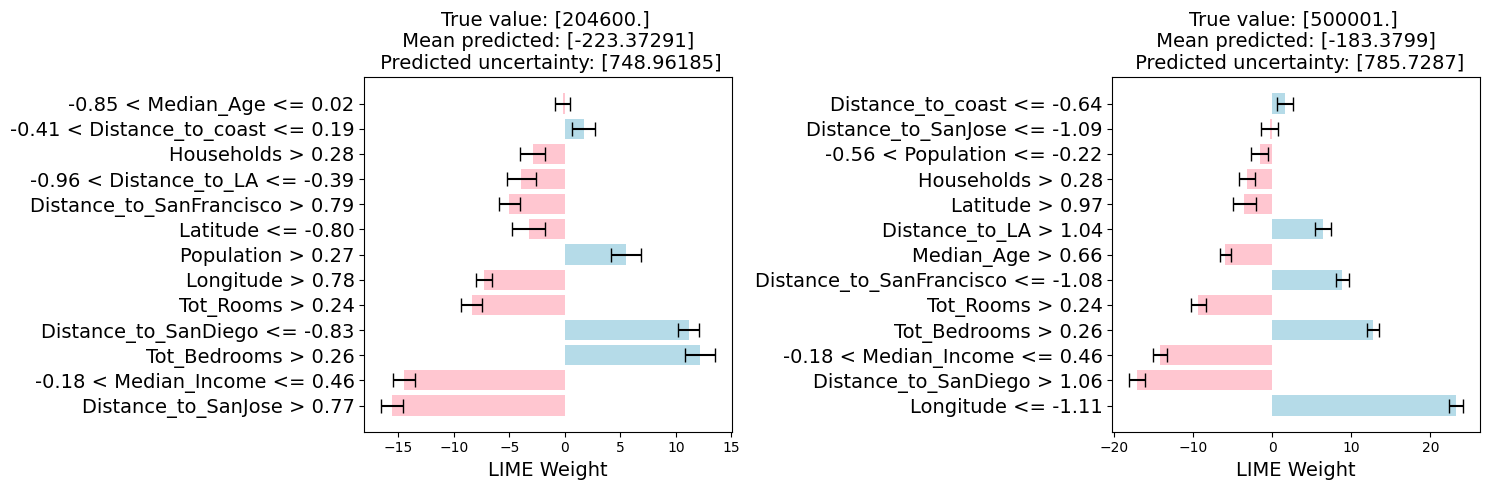

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already defined these variables as in your original code snippet

# Extract data from the DataFrame
features_lime = gbt_cali_selected_explain_lime_unlearn_df['Key'].tolist()
mean_weights_lime = gbt_cali_selected_explain_lime_unlearn_df['Mean'].tolist()
std_weights_lime = gbt_cali_selected_explain_lime_unlearn_df['Std'].tolist()

# Determine colors based on the sign of the mean weights
colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights_lime]

# Number of features per plot
features_per_plot = 13

# Calculate the number of plots needed
num_plots = int(np.ceil(len(features_lime) / features_per_plot))

# Create subplots for all but the last plot
fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes = axes.flatten()  # Flatten the array to make it easier to iterate over

# Loop over the number of plots (except the last one)
for i in range(2):
    # Determine the range of features for this subplot
    start_idx = i * features_per_plot
    end_idx = min(start_idx + features_per_plot, len(features_lime))
    
    # Get the data for this range
    chunk_features = features_lime[start_idx:end_idx]
    chunk_mean_weights = mean_weights_lime[start_idx:end_idx]
    chunk_std_weights = std_weights_lime[start_idx:end_idx]
    chunk_colors = colors[start_idx:end_idx]
    
    # Create the horizontal bar plot for this chunk
    feature_ids = range(len(chunk_mean_weights))
    axes[i].barh(feature_ids, chunk_mean_weights, xerr=chunk_std_weights, capsize=5, alpha=0.9, color=chunk_colors)
    axes[i].set_yticks(feature_ids)
    axes[i].set_yticklabels(chunk_features, fontsize=14)
    axes[i].set_xlabel("LIME Weight", fontsize=14)
    title_true = y_tested_drop.iloc[i].to_numpy()
    title_mean = predictions_mean[i].flatten()
    title_uncertainty = predictions_std[i].flatten()
    print(f"true:{title_true}, mean: {title_mean}, uncertain:{title_uncertainty}")
    # # Check if the values are series and get the first item if so
    # if isinstance(title_true, pd.Series):
    #     title_true = title_true.iloc[0]
    # if isinstance(title_mean, pd.Series):
    #     title_mean = title_mean.iloc[0]
    # if isinstance(title_uncertainty, pd.Series):
    #     title_uncertainty = title_uncertainty.iloc[0]
    axes[i].set_title(f"True value: {title_true} \n Mean predicted: {title_mean} \n Predicted uncertainty: {title_uncertainty}", fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()



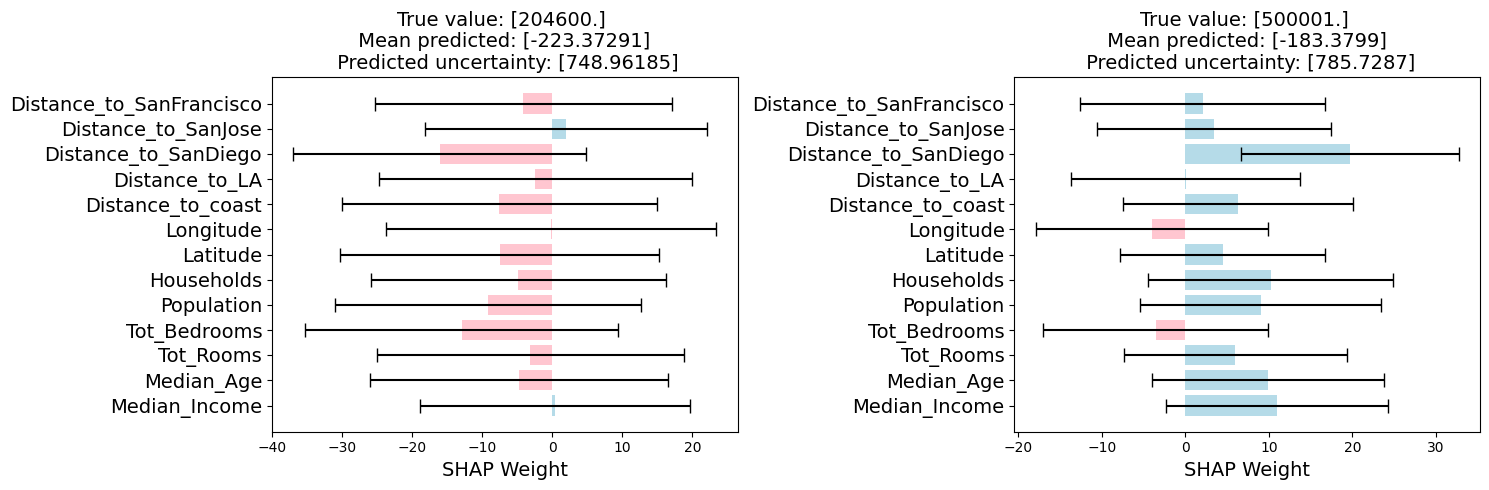

<Figure size 640x480 with 0 Axes>

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already defined these variables as in your original code snippet

# Extract data from the DataFrame
features_shap = flattened_shap_stats_unlearn_df['Feature'].tolist()
mean_weights_shap = flattened_shap_stats_unlearn_df['Mean'].tolist()
std_weights_shap = flattened_shap_stats_unlearn_df['Std'].tolist()

# Determine colors based on the sign of the mean weights
colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights_shap]

# Number of features per plot
features_per_plot = 13

# Calculate the number of plots needed
num_plots = 2

# Create subplots for all but the last plot
fig, axes = plt.subplots(1,2, figsize=(15,5))  # Increase the figure size
axes = axes.flatten()  # Flatten the array to make it easier to iterate over

# Loop over the number of plots (except the last one)
for i in range(num_plots):
    # Determine the range of features for this subplot
    start_idx = i * features_per_plot
    end_idx = min(start_idx + features_per_plot, len(features_shap))
    
    # Get the data for this range
    chunk_features = features_shap[start_idx:end_idx]
    chunk_mean_weights = mean_weights_shap[start_idx:end_idx]
    chunk_std_weights = std_weights_shap[start_idx:end_idx]
    chunk_colors = colors[start_idx:end_idx]
    
    # Create the horizontal bar plot for this chunk
    feature_ids = range(len(chunk_mean_weights))
    axes[i].barh(feature_ids, chunk_mean_weights, xerr=chunk_std_weights, capsize=5, alpha=0.9, color=chunk_colors)
    axes[i].set_yticks(feature_ids)
    axes[i].set_yticklabels(chunk_features, fontsize=14)
    axes[i].set_xlabel("SHAP Weight", fontsize=14)
    title_true = y_tested_drop.iloc[i].to_numpy()
    title_mean = predictions_mean[i].flatten()
    title_uncertainty = predictions_std[i].flatten()
    axes[i].set_title(f"True value: {title_true} \n Mean predicted: {title_mean} \n Predicted uncertainty: {title_uncertainty}", fontsize=14)
    
# Adjust layout
plt.tight_layout()
plt.show()
plt.savefig('../figures/gbt_regress_shap_6_insane.pdf')

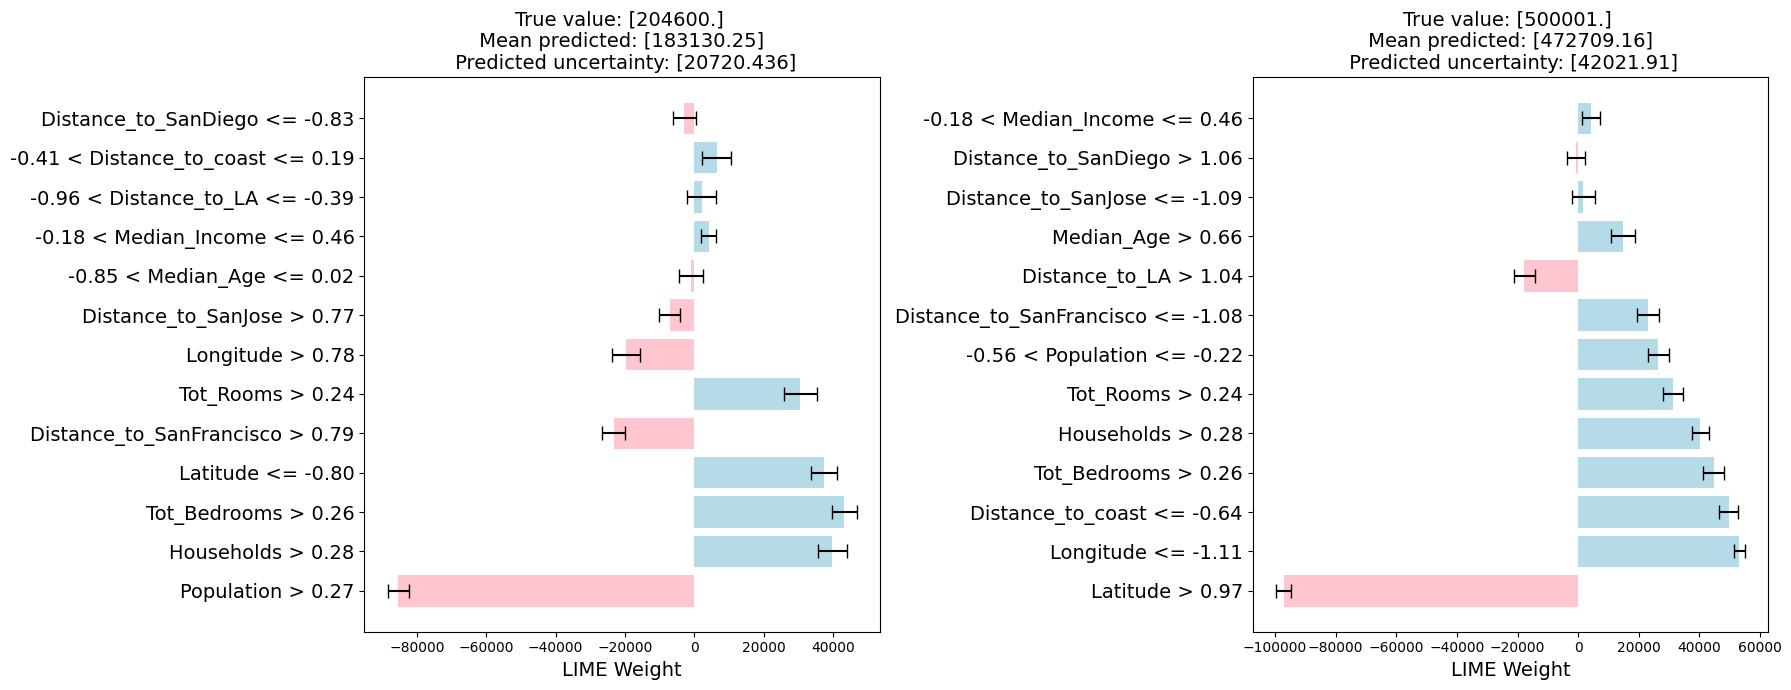

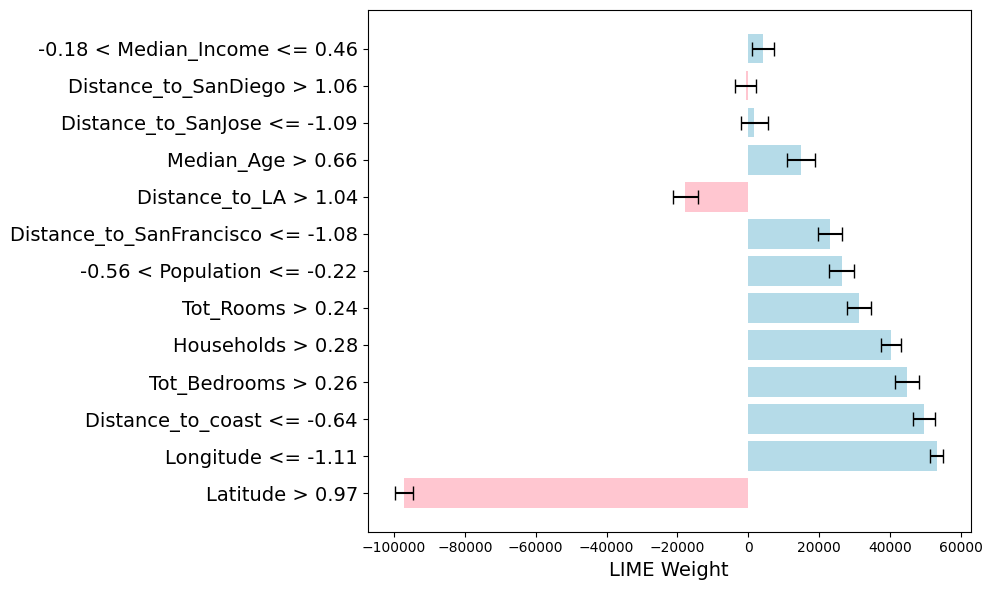

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already defined these variables as in your original code snippet

# Extract data from the DataFrame
features_lime = gbt_cali_selected_explain_lime_unlearn_df['Key'].tolist()
mean_weights_lime = gbt_cali_selected_explain_lime_unlearn_df['Mean'].tolist()
std_weights_lime = gbt_cali_selected_explain_lime_unlearn_df['Std'].tolist()

# Determine colors based on the sign of the mean weights
colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights_lime]

# Number of features per plot
features_per_plot = 13

# Calculate the number of plots needed
num_plots = int(np.ceil(len(features_lime) / features_per_plot))

# Create subplots for all but the last plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes = axes.flatten()  # Flatten the array to make it easier to iterate over

# Loop over the number of plots (except the last one)
for i in range(2):
    # Determine the range of features for this subplot
    start_idx = i * features_per_plot
    end_idx = min(start_idx + features_per_plot, len(features_lime))
    
    # Get the data for this range
    chunk_features = features_lime[start_idx:end_idx]
    chunk_mean_weights = mean_weights_lime[start_idx:end_idx]
    chunk_std_weights = std_weights_lime[start_idx:end_idx]
    chunk_colors = colors[start_idx:end_idx]
    
    # Create the horizontal bar plot for this chunk
    feature_ids = range(len(chunk_mean_weights))
    axes[i].barh(feature_ids, chunk_mean_weights, xerr=chunk_std_weights, capsize=5, alpha=0.9, color=chunk_colors)
    axes[i].set_yticks(feature_ids)
    axes[i].set_yticklabels(chunk_features, fontsize=14)
    axes[i].set_xlabel("LIME Weight", fontsize=14)
    y_test_scaled_selected = y_test.iloc[combined_indices]
    y_test_dropped = y_test_scaled_selected.reset_index(drop=True)
    title_true = y_tested_drop.iloc[i].to_numpy()
    title_mean = predictions_mean[i].flatten()
    title_uncertainty = predictions_std[i].flatten()
    axes[i].set_title(f"True value: {title_true} \n Mean predicted: {title_mean} \n Predicted uncertainty: {title_uncertainty}", fontsize=14)
    
# Adjust layout for the last plot
plt.tight_layout()

# Display all plots
plt.show()


# Plot the last plot separately
last_start_idx = 1 * features_per_plot
last_end_idx = last_start_idx+13

fig_last, ax_last = plt.subplots(figsize=(10, 6))

# Get the data for the last range
chunk_features_last = features_lime[last_start_idx:last_end_idx]
chunk_mean_weights_last = mean_weights_lime[last_start_idx:last_end_idx]
chunk_std_weights_last = std_weights_lime[last_start_idx:last_end_idx]
chunk_colors_last = colors[last_start_idx:last_end_idx]

# Create the horizontal bar plot for the last chunk
feature_ids_last = range(len(chunk_mean_weights_last))
ax_last.barh(feature_ids_last, chunk_mean_weights_last, xerr=chunk_std_weights_last, capsize=5, alpha=0.9, color=chunk_colors_last)
ax_last.set_yticks(feature_ids_last)
ax_last.set_yticklabels(chunk_features_last, fontsize=14)
ax_last.set_xlabel("LIME Weight", fontsize=14)
# ax_last.set_title("Last Chunk of LIME Weights", fontsize=16)

# Adjust layout for the last plot
plt.tight_layout()

# Display all plots
plt.show()


In [45]:
print(num_plots)

6


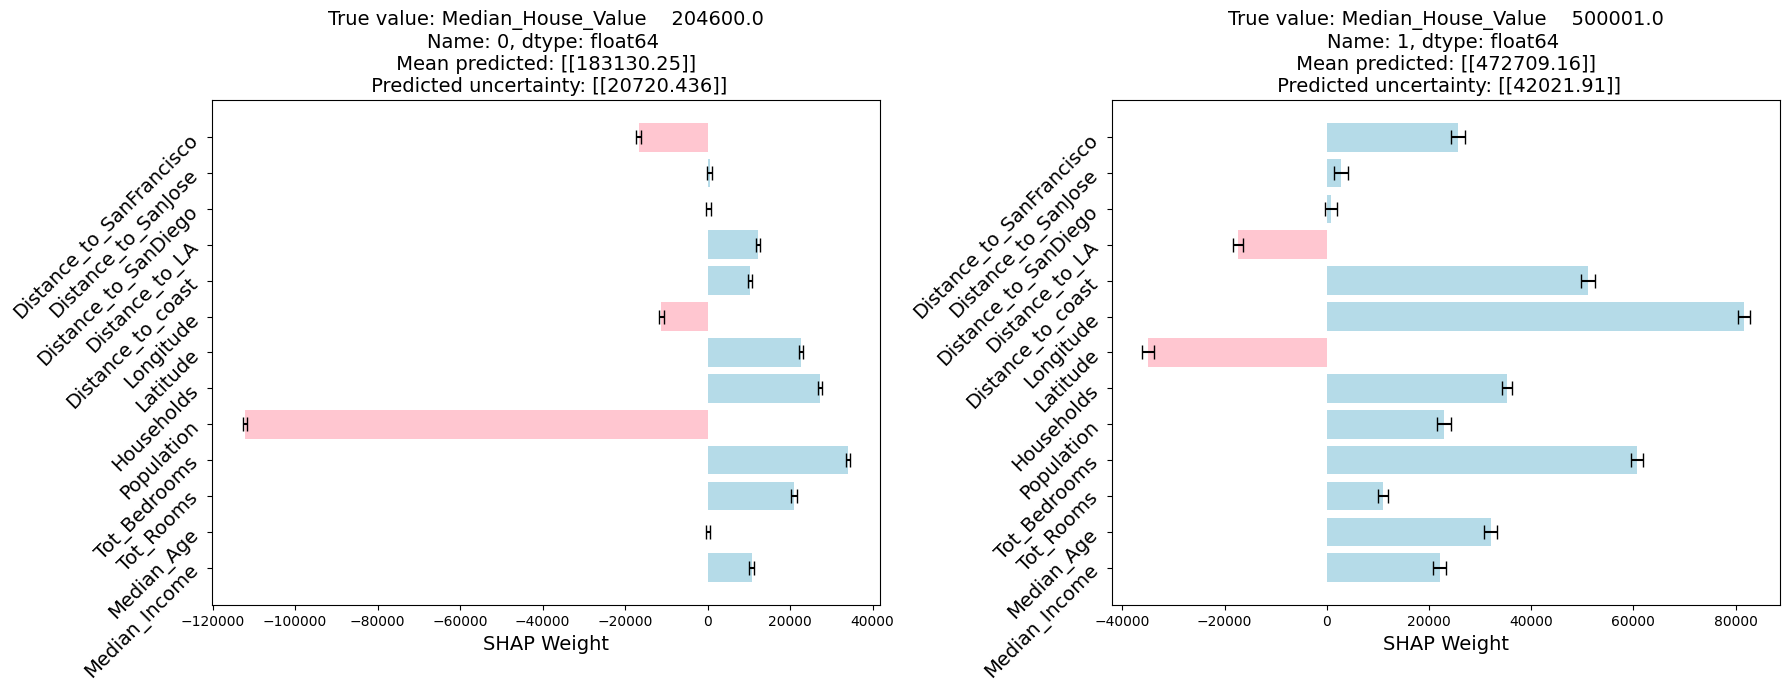

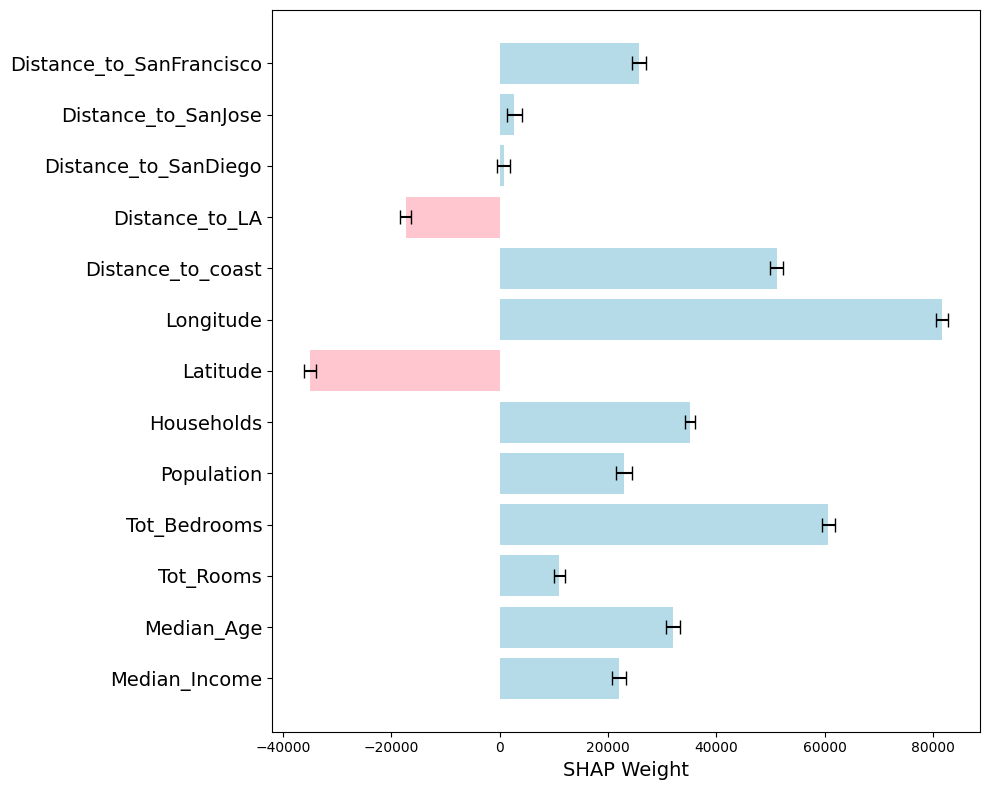

In [94]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already defined these variables as in your original code snippet

# Extract data from the DataFrame
features_shap = flattened_shap_stats_unlearn_df['Feature'].tolist()
mean_weights_shap = flattened_shap_stats_unlearn_df['Mean'].tolist()
std_weights_shap = flattened_shap_stats_unlearn_df['Std'].tolist()

# Determine colors based on the sign of the mean weights
colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights_shap]

# Number of features per plot
features_per_plot = 13

# Calculate the number of plots needed
num_plots = 2

# Create subplots for all but the last plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))  # Increase the figure size
axes = axes.flatten()  # Flatten the array to make it easier to iterate over

# Loop over the number of plots (except the last one)
for i in range(num_plots):
    # Determine the range of features for this subplot
    start_idx = i * features_per_plot
    end_idx = min(start_idx + features_per_plot, len(features_shap))
    
    # Get the data for this range
    chunk_features = features_shap[start_idx:end_idx]
    chunk_mean_weights = mean_weights_shap[start_idx:end_idx]
    chunk_std_weights = std_weights_shap[start_idx:end_idx]
    chunk_colors = colors[start_idx:end_idx]
    
    # Create the horizontal bar plot for this chunk
    feature_ids = range(len(chunk_mean_weights))
    axes[i].barh(feature_ids, chunk_mean_weights, xerr=chunk_std_weights, capsize=5, alpha=0.9, color=chunk_colors)
    axes[i].set_yticks(feature_ids)
    axes[i].set_yticklabels(chunk_features, fontsize=14, rotation=45)
    axes[i].set_xlabel("SHAP Weight", fontsize=14)
    title_true = y_test_dropped.iloc[i]
    title_mean = predictions_mean[i]
    title_uncertainty = predictions_std[i]
    axes[i].set_title(f"True value: {title_true} \n Mean predicted: {title_mean} \n Predicted uncertainty: {title_uncertainty}", fontsize=14)

# Adjust layout for the last plot
plt.tight_layout()

# Display all plots
plt.show()



# Plot the last plot separately
last_start_idx = (num_plots - 1) * features_per_plot
last_end_idx = last_start_idx + 13

fig_last, ax_last = plt.subplots(figsize=(10, 8))

# Get the data for the last range
chunk_features_last = features_shap[last_start_idx:last_end_idx]
chunk_mean_weights_last = mean_weights_shap[last_start_idx:last_end_idx]
chunk_std_weights_last = std_weights_shap[last_start_idx:last_end_idx]
chunk_colors_last = colors[last_start_idx:last_end_idx]

# Create the horizontal bar plot for the last chunk
feature_ids_last = range(len(chunk_mean_weights_last))
ax_last.barh(feature_ids_last, chunk_mean_weights_last, xerr=chunk_std_weights_last, capsize=5, alpha=0.9, color=chunk_colors_last)
ax_last.set_yticks(feature_ids_last)
ax_last.set_yticklabels(chunk_features_last, fontsize=14)
ax_last.set_xlabel("SHAP Weight", fontsize=14)

# Adjust layout for the last plot
plt.tight_layout()

# Display all plots
plt.show()
